In [ ]:
import pandas as pd
df = pd.read_csv('Autism_Screening_Data_Combined.csv')
print("DataFrame loaded successfully. Displaying the first 5 rows:")
df.head()

DataFrame loaded successfully. Displaying the first 5 rows:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jauundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
3,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
4,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES


In [ ]:
df = df[df['Age'] >= 3]
print("DataFrame after filtering out ages less than 3:")
print(df.head())
print(f"New shape of DataFrame: {df.shape}")

DataFrame after filtering out ages less than 3:
   A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age Sex Jauundice Family_ASD Class
0   1   1   0   1   0   0   1   1   0    0   15   m        no         no    NO
1   0   1   1   1   0   1   1   0   1    0   15   m        no         no    NO
2   1   1   1   0   1   1   1   1   1    1   15   f        no        yes   YES
3   1   1   1   1   1   1   1   1   0    0   16   f        no         no   YES
4   1   1   1   1   1   1   1   1   1    1   15   f        no         no   YES
New shape of DataFrame: (5568, 15)


In [ ]:
print("Data types and non-null values:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics for numerical columns:")
print(df.describe())

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
Index: 5568 entries, 0 to 6069
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   A1          5568 non-null   int64 
 1   A2          5568 non-null   int64 
 2   A3          5568 non-null   int64 
 3   A4          5568 non-null   int64 
 4   A5          5568 non-null   int64 
 5   A6          5568 non-null   int64 
 6   A7          5568 non-null   int64 
 7   A8          5568 non-null   int64 
 8   A9          5568 non-null   int64 
 9   A10         5568 non-null   int64 
 10  Age         5568 non-null   int64 
 11  Sex         5568 non-null   object
 12  Jauundice   5568 non-null   object
 13  Family_ASD  5568 non-null   object
 14  Class       5568 non-null   object
dtypes: int64(11), object(4)
memory usage: 696.0+ KB

Missing values per column:
A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7       

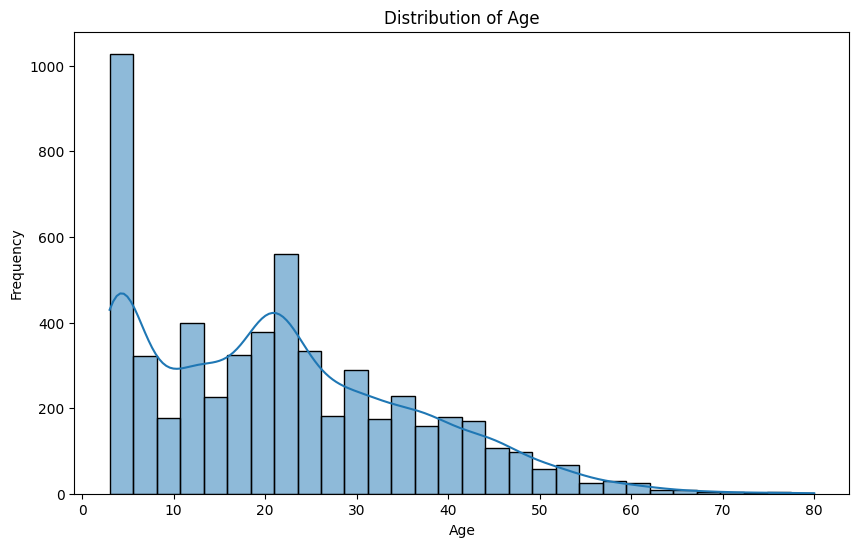

Histogram of Age distribution displayed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print("Histogram of Age distribution displayed.")

/tmp/ipython-input-3859259210.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-3859259210.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-3859259210.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipython-input-3859259210.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

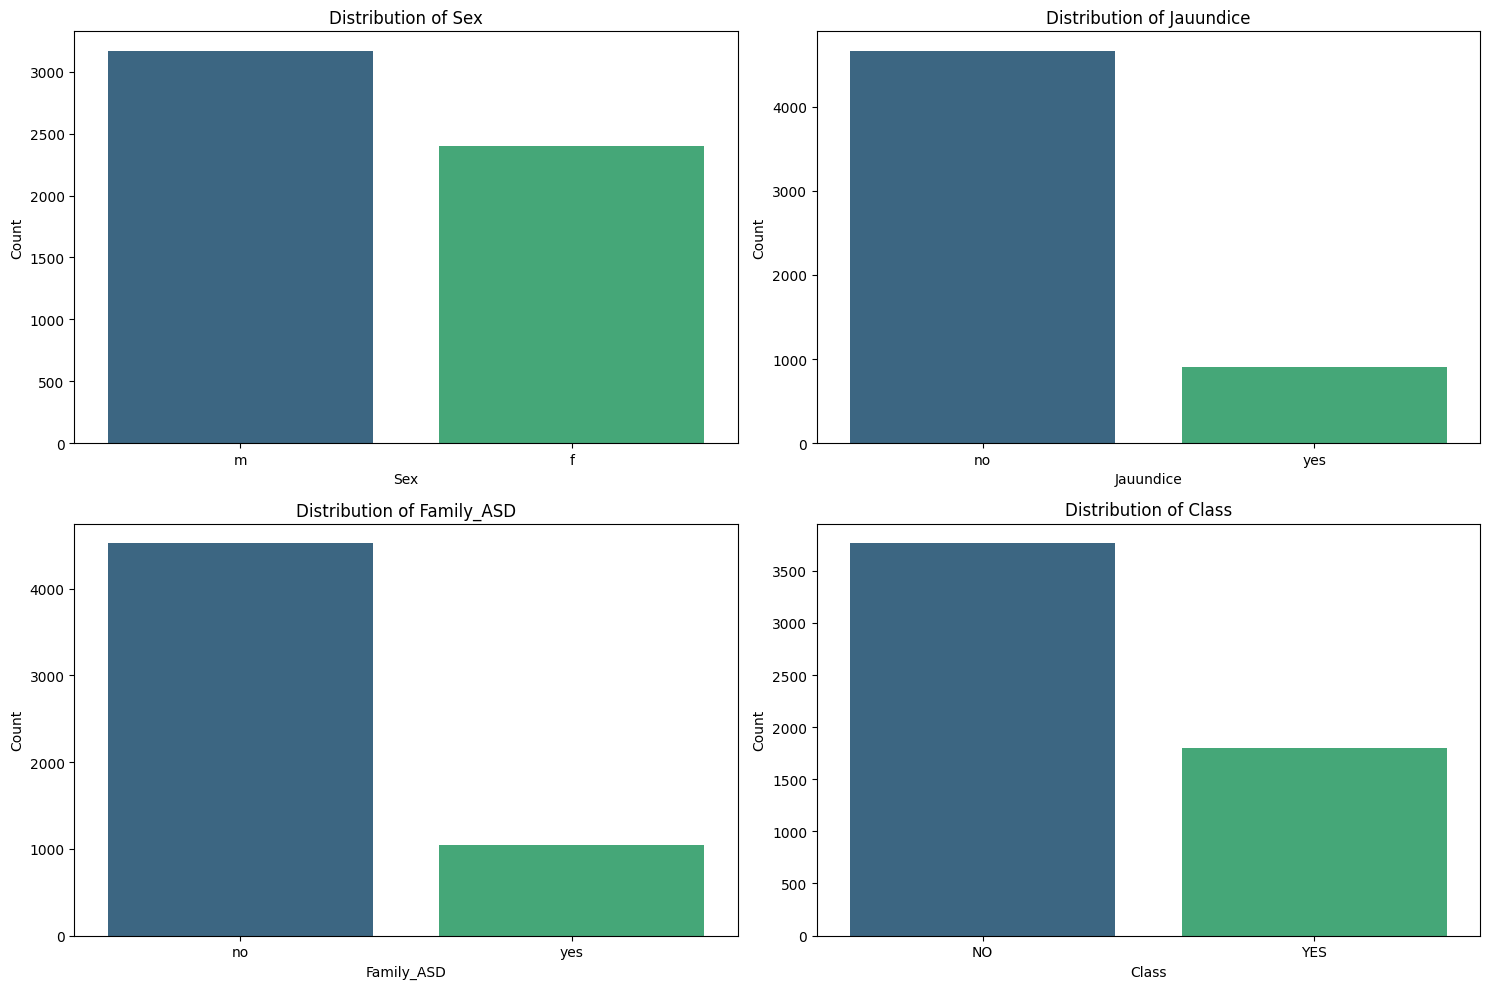

Count plots for categorical features displayed.


In [ ]:
categorical_cols = ['Sex', 'Jauundice', 'Family_ASD', 'Class']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Count plots for categorical features displayed.")

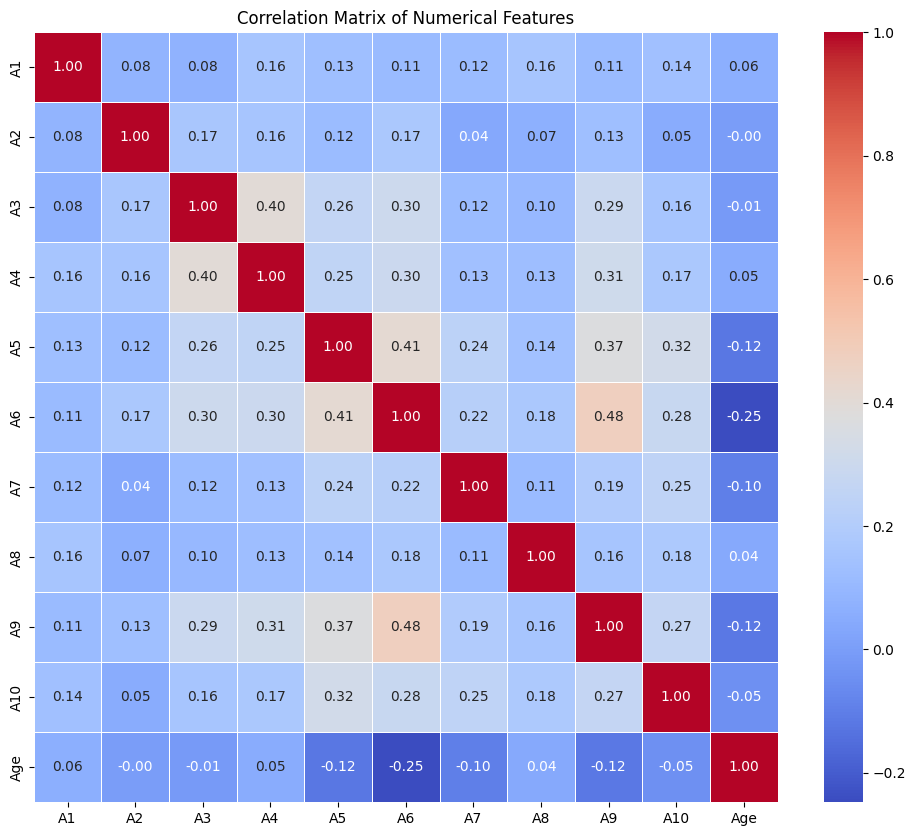

Correlation matrix heatmap for numerical features displayed.


In [ ]:
numerical_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
print("Correlation matrix heatmap for numerical features displayed.")

In [ ]:
df_kids = df[(df['Age'] >= 3) & (df['Age'] <= 12)].copy()
df_adults = df[df['Age'] > 12].copy()

print(f"Shape of df_kids: {df_kids.shape}")
print(f"Shape of df_adults: {df_adults.shape}")
print("DataFrames for kids and adults created based on age criteria.")

Shape of df_kids: (1796, 15)
Shape of df_adults: (3772, 15)
DataFrames for kids and adults created based on age criteria.


In [ ]:
df_kids['Class'] = df_kids['Class'].map({'NO': 0, 'YES': 1})
df_adults['Class'] = df_adults['Class'].map({'NO': 0, 'YES': 1})

print("\nHead of df_kids after target variable conversion:")
print(df_kids.head())
print(f"Shape of df_kids: {df_kids.shape}")

print("\nHead of df_adults after target variable conversion:")
print(df_adults.head())
print(f"Shape of df_adults: {df_adults.shape}")
print("Target variable 'Class' converted to numerical format for both kids and adults DataFrames.")


Head of df_kids after target variable conversion:
    A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age Sex Jauundice Family_ASD  \
7    1   0   0   0   1   0   0   1   0    1   12   m        no         no   
9    0   1   1   1   0   1   1   0   1    0   12   f        no         no   
12   0   0   0   1   1   1   1   1   1    0   12   m       yes        yes   
16   0   0   0   0   0   0   0   0   1    1   12   f        no         no   
18   0   0   0   0   0   0   0   0   1    1   12   f        no         no   

    Class  
7       0  
9       0  
12      0  
16      0  
18      0  
Shape of df_kids: (1796, 15)

Head of df_adults after target variable conversion:
   A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age Sex Jauundice Family_ASD  \
0   1   1   0   1   0   0   1   1   0    0   15   m        no         no   
1   0   1   1   1   0   1   1   0   1    0   15   m        no         no   
2   1   1   1   0   1   1   1   1   1    1   15   f        no        yes   
3   1   1   1   1   1   1   

In [ ]:
X_kids = df_kids.drop('Class', axis=1)
y_kids = df_kids['Class']

print("Features (X_kids) and target (y_kids) separated for kids dataset.")
print(f"X_kids shape: {X_kids.shape}")
print(f"y_kids shape: {y_kids.shape}")

Features (X_kids) and target (y_kids) separated for kids dataset.
X_kids shape: (1796, 14)
y_kids shape: (1796,)


In [ ]:
X_kids_categorical = pd.DataFrame(index=X_kids.index)
X_kids_categorical['Sex'] = X_kids['Sex'].map({'f': 0, 'm': 1})
X_kids_categorical['Jauundice'] = X_kids['Jauundice'].map({'no': 0, 'yes': 1})
X_kids_categorical['Family_ASD'] = X_kids['Family_ASD'].map({'no': 0, 'yes': 1})

print("Categorical features for kids dataset converted to numerical format.")
print(f"X_kids_categorical shape: {X_kids_categorical.shape}")
print(X_kids_categorical.head())

Categorical features for kids dataset converted to numerical format.
X_kids_categorical shape: (1796, 3)
    Sex  Jauundice  Family_ASD
7     1          0           0
9     0          0           0
12    1          1           1
16    0          0           0
18    0          0           0


In [ ]:
numerical_cols_kids = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age']
X_kids_numerical = X_kids[numerical_cols_kids]

print("Numerical features for kids dataset identified.")
print(f"X_kids_numerical shape: {X_kids_numerical.shape}")
print(X_kids_numerical.head())

Numerical features for kids dataset identified.
X_kids_numerical shape: (1796, 11)
    A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age
7    1   0   0   0   1   0   0   1   0    1   12
9    0   1   1   1   0   1   1   0   1    0   12
12   0   0   0   1   1   1   1   1   1    0   12
16   0   0   0   0   0   0   0   0   1    1   12
18   0   0   0   0   0   0   0   0   1    1   12


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_kids_scaled = scaler.fit_transform(X_kids_numerical)
X_kids_scaled_df = pd.DataFrame(X_kids_scaled, columns=numerical_cols_kids, index=X_kids_numerical.index)

print("Numerical features for kids dataset scaled.")
print(f"X_kids_scaled_df shape: {X_kids_scaled_df.shape}")
print(X_kids_scaled_df.head())

Numerical features for kids dataset scaled.
X_kids_scaled_df shape: (1796, 11)
          A1        A2        A3        A4        A5        A6        A7  \
7   0.739555 -1.001114 -1.204244 -1.049088  0.755846 -1.323020 -1.182313   
9  -1.352164  0.998887  0.830396  0.953209 -1.323020  0.755846  0.845800   
12 -1.352164 -1.001114 -1.204244  0.953209  0.755846  0.755846  0.845800   
16 -1.352164 -1.001114 -1.204244 -1.049088 -1.323020 -1.323020 -1.182313   
18 -1.352164 -1.001114 -1.204244 -1.049088 -1.323020 -1.323020 -1.182313   

          A8        A9       A10       Age  
7   1.008949 -0.998887  0.735956  1.935329  
9  -0.991131  1.001114 -1.358777  1.935329  
12  1.008949  1.001114 -1.358777  1.935329  
16 -0.991131  1.001114  0.735956  1.935329  
18 -0.991131  1.001114  0.735956  1.935329  


In [ ]:
X_kids_processed = pd.concat([X_kids_scaled_df, X_kids_categorical], axis=1)

print("Complete processed feature set (X_kids_processed) created.")
print(f"X_kids_processed shape: {X_kids_processed.shape}")
print(X_kids_processed.head())

Complete processed feature set (X_kids_processed) created.
X_kids_processed shape: (1796, 14)
          A1        A2        A3        A4        A5        A6        A7  \
7   0.739555 -1.001114 -1.204244 -1.049088  0.755846 -1.323020 -1.182313   
9  -1.352164  0.998887  0.830396  0.953209 -1.323020  0.755846  0.845800   
12 -1.352164 -1.001114 -1.204244  0.953209  0.755846  0.755846  0.845800   
16 -1.352164 -1.001114 -1.204244 -1.049088 -1.323020 -1.323020 -1.182313   
18 -1.352164 -1.001114 -1.204244 -1.049088 -1.323020 -1.323020 -1.182313   

          A8        A9       A10       Age  Sex  Jauundice  Family_ASD  
7   1.008949 -0.998887  0.735956  1.935329    1          0           0  
9  -0.991131  1.001114 -1.358777  1.935329    0          0           0  
12  1.008949  1.001114 -1.358777  1.935329    1          1           1  
16 -0.991131  1.001114  0.735956  1.935329    0          0           0  
18 -0.991131  1.001114  0.735956  1.935329    0          0           0  


In [ ]:
from sklearn.model_selection import train_test_split

X_train_kids, X_test_kids, y_train_kids, y_test_kids = train_test_split(X_kids_processed, y_kids, test_size=0.3, random_state=42)

print("Kids dataset split into training and testing sets.")
print(f"X_train_kids shape: {X_train_kids.shape}")
print(f"X_test_kids shape: {X_test_kids.shape}")
print(f"y_train_kids shape: {y_train_kids.shape}")
print(f"y_test_kids shape: {y_test_kids.shape}")

Kids dataset split into training and testing sets.
X_train_kids shape: (1257, 14)
X_test_kids shape: (539, 14)
y_train_kids shape: (1257,)
y_test_kids shape: (539,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
param_grid_rf_kids = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
grid_search_rf_kids = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf_kids, cv=5, scoring='f1', n_jobs=-1)

In [ ]:
grid_search_rf_kids.fit(X_train_kids, y_train_kids)

print("GridSearchCV for Random Forest (kids) fitted to training data.")
print(f"Best parameters for Random Forest (kids): {grid_search_rf_kids.best_params_}")
print(f"Best F1-score for Random Forest (kids): {grid_search_rf_kids.best_score_:.4f}")

GridSearchCV for Random Forest (kids) fitted to training data.
Best parameters for Random Forest (kids): {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
Best F1-score for Random Forest (kids): 0.9408


In [ ]:
X_adults = df_adults.drop('Class', axis=1)
y_adults = df_adults['Class']

print("Features (X_adults) and target (y_adults) separated for adults dataset.")
print(f"X_adults shape: {X_adults.shape}")
print(f"y_adults shape: {y_adults.shape}")

Features (X_adults) and target (y_adults) separated for adults dataset.
X_adults shape: (3772, 14)
y_adults shape: (3772,)


In [ ]:
X_adults_categorical = pd.DataFrame(index=X_adults.index)
X_adults_categorical['Sex'] = X_adults['Sex'].map({'f': 0, 'm': 1})
X_adults_categorical['Jauundice'] = X_adults['Jauundice'].map({'no': 0, 'yes': 1})
X_adults_categorical['Family_ASD'] = X_adults['Family_ASD'].map({'no': 0, 'yes': 1})

print("Categorical features for adults dataset converted to numerical format.")
print(f"X_adults_categorical shape: {X_adults_categorical.shape}")
print(X_adults_categorical.head())

Categorical features for adults dataset converted to numerical format.
X_adults_categorical shape: (3772, 3)
   Sex  Jauundice  Family_ASD
0    1          0           0
1    1          0           0
2    0          0           1
3    0          0           0
4    0          0           0


In [ ]:
numerical_cols_adults = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age']
X_adults_numerical = X_adults[numerical_cols_adults]

print("Numerical features for adults dataset identified.")
print(f"X_adults_numerical shape: {X_adults_numerical.shape}")
print(X_adults_numerical.head())

Numerical features for adults dataset identified.
X_adults_numerical shape: (3772, 11)
   A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age
0   1   1   0   1   0   0   1   1   0    0   15
1   0   1   1   1   0   1   1   0   1    0   15
2   1   1   1   0   1   1   1   1   1    1   15
3   1   1   1   1   1   1   1   1   0    0   16
4   1   1   1   1   1   1   1   1   1    1   15


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_adults = StandardScaler()
X_adults_scaled = scaler_adults.fit_transform(X_adults_numerical)
X_adults_scaled_df = pd.DataFrame(X_adults_scaled, columns=numerical_cols_adults, index=X_adults_numerical.index)

print("Numerical features for adults dataset scaled.")
print(f"X_adults_scaled_df shape: {X_adults_scaled_df.shape}")
print(X_adults_scaled_df.head())

Numerical features for adults dataset scaled.
X_adults_scaled_df shape: (3772, 11)
         A1        A2        A3        A4        A5        A6        A7  \
0  0.607575  1.038933 -1.043357  0.896617 -1.001061 -0.707388  1.140175   
1 -1.645888  1.038933  0.958445  0.896617 -1.001061  1.413651  1.140175   
2  0.607575  1.038933  0.958445 -1.115304  0.998940  1.413651  1.140175   
3  0.607575  1.038933  0.958445  0.896617  0.998940  1.413651  1.140175   
4  0.607575  1.038933  0.958445  0.896617  0.998940  1.413651  1.140175   

         A8        A9       A10       Age  
0  0.867164 -0.788017 -1.167651 -1.186230  
1 -1.153184  1.269008 -1.167651 -1.186230  
2  0.867164  1.269008  0.856420 -1.186230  
3  0.867164 -0.788017 -1.167651 -1.100766  
4  0.867164  1.269008  0.856420 -1.186230  


In [ ]:
X_adults_processed = pd.concat([X_adults_scaled_df, X_adults_categorical], axis=1)

print("Complete processed feature set (X_adults_processed) created.")
print(f"X_adults_processed shape: {X_adults_processed.shape}")
print(X_adults_processed.head())

Complete processed feature set (X_adults_processed) created.
X_adults_processed shape: (3772, 14)
         A1        A2        A3        A4        A5        A6        A7  \
0  0.607575  1.038933 -1.043357  0.896617 -1.001061 -0.707388  1.140175   
1 -1.645888  1.038933  0.958445  0.896617 -1.001061  1.413651  1.140175   
2  0.607575  1.038933  0.958445 -1.115304  0.998940  1.413651  1.140175   
3  0.607575  1.038933  0.958445  0.896617  0.998940  1.413651  1.140175   
4  0.607575  1.038933  0.958445  0.896617  0.998940  1.413651  1.140175   

         A8        A9       A10       Age  Sex  Jauundice  Family_ASD  
0  0.867164 -0.788017 -1.167651 -1.186230    1          0           0  
1 -1.153184  1.269008 -1.167651 -1.186230    1          0           0  
2  0.867164  1.269008  0.856420 -1.186230    0          0           1  
3  0.867164 -0.788017 -1.167651 -1.100766    0          0           0  
4  0.867164  1.269008  0.856420 -1.186230    0          0           0  


In [ ]:
from sklearn.model_selection import train_test_split

X_train_adults, X_test_adults, y_train_adults, y_test_adults = train_test_split(X_adults_processed, y_adults, test_size=0.3, random_state=42)

print("Adults dataset split into training and testing sets.")
print(f"X_train_adults shape: {X_train_adults.shape}")
print(f"X_test_adults shape: {X_test_adults.shape}")
print(f"y_train_adults shape: {y_train_adults.shape}")
print(f"y_test_adults shape: {y_test_adults.shape}")

Adults dataset split into training and testing sets.
X_train_adults shape: (2640, 14)
X_test_adults shape: (1132, 14)
y_train_adults shape: (2640,)
y_test_adults shape: (1132,)


In [ ]:
param_grid_rf_adults = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf_adults = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf_adults, cv=5, scoring='f1', n_jobs=-1)

In [ ]:
grid_search_rf_adults.fit(X_train_adults, y_train_adults)

print("GridSearchCV for Random Forest (adults) fitted to training data.")
print(f"Best parameters for Random Forest (adults): {grid_search_rf_adults.best_params_}")
print(f"Best F1-score for Random Forest (adults): {grid_search_rf_adults.best_score_:.4f}")

GridSearchCV for Random Forest (adults) fitted to training data.
Best parameters for Random Forest (adults): {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Best F1-score for Random Forest (adults): 0.9600


In [ ]:
from sklearn.metrics import accuracy_score

# Evaluate the best model for kids
best_rf_kids = grid_search_rf_kids.best_estimator_
y_pred_kids = best_rf_kids.predict(X_test_kids)
accuracy_kids = accuracy_score(y_test_kids, y_pred_kids)
print(f"Accuracy for Kids Random Forest Model: {accuracy_kids:.4f}")

# Evaluate the best model for adults
best_rf_adults = grid_search_rf_adults.best_estimator_
y_pred_adults = best_rf_adults.predict(X_test_adults)
accuracy_adults = accuracy_score(y_test_adults, y_pred_adults)
print(f"Accuracy for Adults Random Forest Model: {accuracy_adults:.4f}")

Accuracy for Kids Random Forest Model: 0.9647
Accuracy for Adults Random Forest Model: 0.9841


# Task
Generate classification reports and plot confusion matrices for both the kids' and adults' Random Forest models using `y_test_kids`, `y_pred_kids`, `y_test_adults`, and `y_pred_adults`.

## Generate Classification Report for Kids Model

### Subtask:
Generate and display a classification report for the kids' Random Forest model using `y_test_kids` and `y_pred_kids`.


**Reasoning**:
To generate the classification report, I need to import the `classification_report` function from `sklearn.metrics` and then use it with the true labels (`y_test_kids`) and predicted labels (`y_pred_kids`) for the kids' dataset.



In [ ]:
from sklearn.metrics import classification_report

# Generate classification report for kids model
report_kids = classification_report(y_test_kids, y_pred_kids)
print("Classification Report for Kids Random Forest Model:")
print(report_kids)

Classification Report for Kids Random Forest Model:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       358
           1       0.98      0.92      0.95       181

    accuracy                           0.96       539
   macro avg       0.97      0.95      0.96       539
weighted avg       0.97      0.96      0.96       539



**Reasoning**:
Now that the classification report for the kids' model has been generated and displayed, the next step is to generate and display the classification report for the adults' Random Forest model using `y_test_adults` and `y_pred_adults`.



In [ ]:
report_adults = classification_report(y_test_adults, y_pred_adults)
print("Classification Report for Adults Random Forest Model:")
print(report_adults)

Classification Report for Adults Random Forest Model:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       761
           1       0.98      0.98      0.98       371

    accuracy                           0.98      1132
   macro avg       0.98      0.98      0.98      1132
weighted avg       0.98      0.98      0.98      1132



**Reasoning**:
I need to generate a confusion matrix for the kids' Random Forest model. This involves importing `confusion_matrix` from `sklearn.metrics` and `seaborn` and `matplotlib.pyplot` for plotting, then using the true and predicted labels to create and display the matrix.



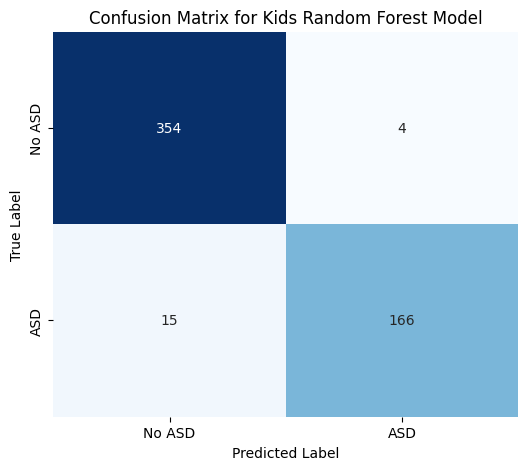

Confusion matrix for kids model displayed.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix for kids model
cm_kids = confusion_matrix(y_test_kids, y_pred_kids)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_kids, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No ASD', 'ASD'], yticklabels=['No ASD', 'ASD'])
plt.title('Confusion Matrix for Kids Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("Confusion matrix for kids model displayed.")

**Reasoning**:
Now that the confusion matrix for the kids' model has been generated and displayed, the next step is to generate and display the confusion matrix for the adults' Random Forest model using `y_test_adults` and `y_pred_adults`.



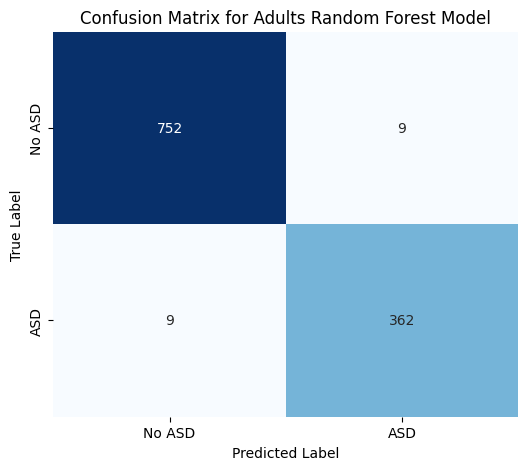

Confusion matrix for adults model displayed.


In [ ]:
cm_adults = confusion_matrix(y_test_adults, y_pred_adults)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_adults, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No ASD', 'ASD'], yticklabels=['No ASD', 'ASD'])
plt.title('Confusion Matrix for Adults Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("Confusion matrix for adults model displayed.")

In [ ]:
import pickle

# Export Kids Random Forest Model
with open('kids_model.pkl', 'wb') as f:
    pickle.dump(best_rf_kids, f)
print("Kids Random Forest Model exported as 'best_rf_kids_model.pkl'.")

# Export Adults Random Forest Model
with open('adult_model.pkl', 'wb') as f:
    pickle.dump(best_rf_adults, f)
print("Adults Random Forest Model exported as 'best_rf_adults_model.pkl'.")

Kids Random Forest Model exported as 'best_rf_kids_model.pkl'.
Adults Random Forest Model exported as 'best_rf_adults_model.pkl'.
